# FashionMNIST 데이터셋 이미지 생성

## 들어가며

목표

모델을 활용하여 FashionMNIST 데이터셋의 각 패션 아이템(예: 티셔츠, 바지, 스니커즈 등)을 조건부로 생성하는 작업을 수행

각 클래스에 해당하는 이미지를 생성하는 cGAN (Conditional GAN) 모델을 직접 설계, 학습

사용 데이터셋


28 x 28의 이미지의 10개의 클래스를 가지고 있는 Fashion MNIST 데이터셋

클래스 :
- T-shirt/top

- Trouser

- Pullover

- Dress

- Coat

- Sandal

- Shirt

- Sneaker

- Bag

- Ankle boot

사용 모델
|모델|조건 추가 방식|비고|
|---|---|---|
|GAN|One-Hot-Encoding|클래스 수인 10차원으로 인코딩|
|GAN|Embedding|One-Hot과 비교 위해 10차원으로 임베딩|
|LDM|One-Hot-Encoding|FID 계산 Feature 수 GAN과 상이|

비교 목표

- One-Hot Encoding과 Embedding방식의 성능 차이 비교

- GAN과 LDM의 생성 이미지 차이 비교



> FashionMNIST같은 간단한 데이터셋에서 조건 추가 방식의 차이와 GAN vs LDM의 이미지 차이는 어떠한가 ?




## 파이프라인

1. 데이터 EDA
2. 데이터 전처리/ 로더생성
3. 모델링 - GAN
4. 모델 학습 / 조건 추가 방식 비교
5. LDM 모델링 / 성능지표, 생성 이미지 비교
6. 결론


## Imports

In [1]:
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.1 MB/s eta 0:00:00


In [2]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import matplotlib.image as mpimg
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image.fid import FrechetInceptionDistance

## 1\. 데이터 EDA

### 1-1. 데이터 불러오기

In [3]:
dataset = datasets.FashionMNIST(
    root='./data',     # 데이터를 저장할 폴더 경로
    train=True,        # True = 학습용(60,000장) / False = 테스트용(10,000장)
    download=True,     # 해당 경로에 데이터 없으면 자동으로 다운로드
    transform=None # 이미지에 적용할 전처리
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.3MB/s]


In [4]:
#경로 지정
data_dir = './data/FashionMNIST'
raw_data_dir = os.path.join(data_dir, 'raw')


In [5]:
for file in os.listdir(raw_data_dir):
    print(file)

train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte.gz
t10k-labels-idx1-ubyte
train-images-idx3-ubyte
train-labels-idx1-ubyte.gz
t10k-images-idx3-ubyte.gz
t10k-images-idx3-ubyte
train-labels-idx1-ubyte


- train-images-idx3-ubyte : 학습 이미지 60,000장

- train-labels-idx1-ubyte : 학습 라벨 60,000개

- t10k-images-idx3-ubyte : 테스트 이미지 10,000장

- t10k-labels-idx1-ubyte : 테스트 라벨 10,000개

본래 FashionMINST 데이터셋은 분류에 이용되는 데이터셋이기 때문에 test dataset이 따로 있지만, 이미지 생성 태스크에서는 필요하지 않기 때문에 train dataset 60000장만 사용하기로 했다.

In [6]:
# 데이터셋 전체 크기
print(f"데이터 수: {len(dataset)}")

# 이미지 한 장 크기
image, label = dataset[0]
print(f"이미지 shape: {image.size}")
#이미지 색상공간
print(f"이미지 색상공간 : {image.mode}")

데이터 수: 60000
이미지 shape: (28, 28)
이미지 색상공간 : L


### 1-2. 클래스 확인

클래스 목록: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
T-shirt/top: 6000장
Trouser: 6000장
Pullover: 6000장
Dress: 6000장
Coat: 6000장
Sandal: 6000장
Shirt: 6000장
Sneaker: 6000장
Bag: 6000장
Ankle boot: 6000장


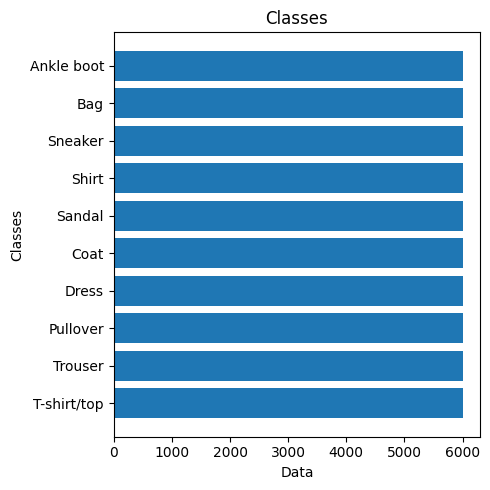

In [7]:
# 클래스 리스트 확인
class_names = dataset.classes
print(f"클래스 목록: {class_names}")

# 클래스별 데이터 수 확인
labels = [label for _, label in dataset]
unique, counts = np.unique(labels, return_counts=True)

for name, count in zip(class_names, counts):
    print(f"{name}: {count}장")

# 클래스 분포 시각화
plt.figure(figsize=(5, 5))
plt.barh(class_names, counts)
plt.title('Classes')
plt.xlabel('Data')
plt.ylabel('Classes')
plt.tight_layout()
plt.show()

균등하게 6000장씩 데이터가 분배되어있는걸 확인할 수 있었다.

### 1-3. 이미지 확인

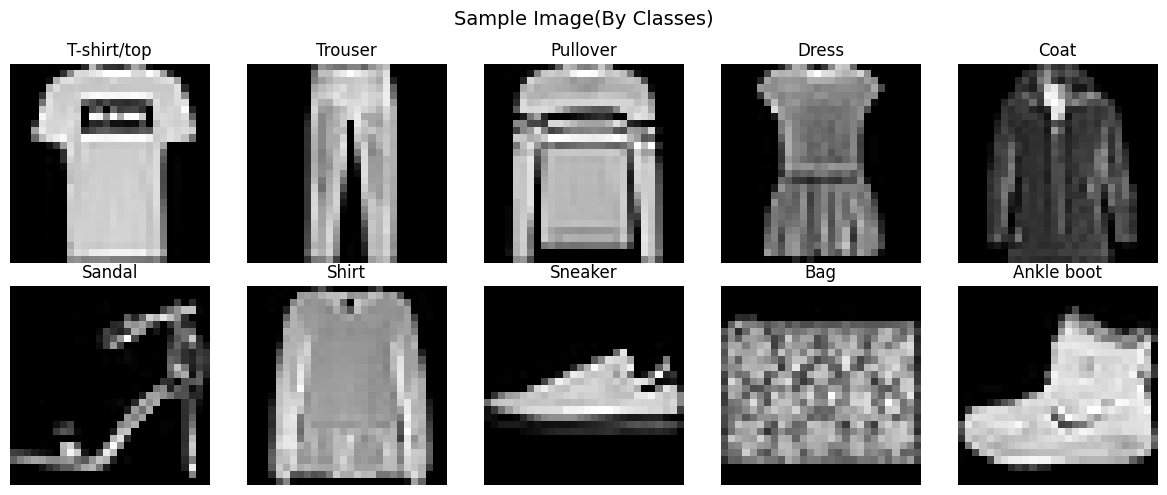

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flatten()):
    # 각 클래스에서 이미지 하나씩 꺼내기
    idx = next(j for j, (_, label) in enumerate(dataset) if label == i)
    image, label = dataset[idx]

    ax.imshow(image, cmap='gray')
    ax.set_title(class_names[i])
    ax.axis('off')

plt.suptitle('Sample Image(By Classes)', fontsize=14)
plt.tight_layout()
plt.show()

이미지 크기가 28x28로 크지 않아, 선명하게 보이지는 않는다.

## 2\. 데이터 전처리/ 로더 생성

Custom한 데이터셋을 만들 필요 없이, datasets.FashionMNIST를 이용하여 데이터로더를 생성했다.

In [9]:
#transform 정의
my_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # 데이터 증강 : 좌우 반전
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) #tanh위해서 [-1, 1]범위로 초기화
])

In [10]:
#본격적으로 transform 적용한 데이터셋 불러오기
ds = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=my_transform
)

loader = DataLoader(
    ds,
    batch_size=128,
    shuffle=True,
    num_workers = 2,
    pin_memory = True
)

## 3\. 모델링

### 3-1. Generator 생성

one-hot으로 인코딩하여 채널을 추가하는 버전과, nn.Embedding을 활용하여 채널을 추가하는 버전을 만들었다.

one-hot encoding 버전 : torch.cat을 활용해 라벨 데이터를 추가했고, one-hot encoding 되어서 총 차원 수는 클래스 수인 10개가 늘어나게 된다.

In [11]:
#생성자 정의 - one-hot 버전
class Generator_OneHot(nn.Module):

    def __init__(self, noise_dim, num_classes=10):
        super(Generator_OneHot, self).__init__()

        # noise_dim + num_classes (100 + 10 = 110)
        self.upsample = nn.Sequential(
            #커널 크기를 7로 하여 출력 크기를 28 / 4 = 7로 맞
            nn.ConvTranspose2d(noise_dim + num_classes, 128, 7, 1, 0, bias=False),  # (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  # (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            #최종 출력 : 흑백 이미지
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),    # (1, 28, 28)
        )
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        # label → one-hot encoding
        label_onehot = F.one_hot(label, num_classes=10)         # (batch, 10)
        label_onehot = label_onehot.view(-1, 10, 1, 1).float() # (batch, 10, 1, 1)

        x = torch.cat([noise, label_onehot], dim=1)            # (batch, 110, 1, 1)
        x = self.upsample(x)
        x = self.tanh(x)
        return x

Embedding을 사용하는 버전에서는 one-hot인코딩을 하는 버전과 공평하게  입력 채널 수를 맞춰주기 위해서 embedded 차원을 10으로 특정했다.

In [12]:
#생성자 정의 - nn.Embedding 버전
class Generator_Embedding(nn.Module):

    def __init__(self, noise_dim, num_classes=10, embed_dim=10):
        super(Generator_Embedding, self).__init__()

        # 라벨 임베딩
        self.embedding = nn.Embedding(num_classes, embed_dim)

        # noise_dim + embed_dim (100 + 10 = 110)
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(noise_dim + embed_dim, 128, 7, 1, 0, bias=False),  # (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  # (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),    # (1, 28, 28)
        )
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        #라벨 : nn.Embedding
        embed = self.embedding(label)               # (batch, 10)
        embed = embed.view(-1, 10, 1, 1)            # (batch, 10, 1, 1)

        x = torch.cat([noise, embed], dim=1)        # (batch, 110, 1, 1)
        x = self.upsample(x)
        x = self.tanh(x)
        return x

Generator 출력 shape, 초기 이미지를 확인하여 올바르게 설계가 되었는지 확인했다.

In [13]:
# 테스트용 입력
noise = torch.randn(1, 100, 1, 1)  # batch=1, noise_dim=100
label = torch.tensor([0])           # 클래스 0 (T-shirt/Top)

# one-hot Generator 확인
g_onehot = Generator_OneHot(noise_dim=100, num_classes=10)
fake_onehot = g_onehot(noise, label)
print(f'[one-hot] fake image shape : {fake_onehot.shape}')
# 예상: torch.Size([1, 1, 28, 28]) ✅

# Embedding Generator 확인
g_embed = Generator_Embedding(noise_dim=100, num_classes=10, embed_dim=10)
fake_embed = g_embed(noise, label)
print(f'[Embedding] fake image shape : {fake_embed.shape}')
# 예상: torch.Size([1, 1, 28, 28]) ✅

[one-hot] fake image shape : torch.Size([1, 1, 28, 28])
[Embedding] fake image shape : torch.Size([1, 1, 28, 28])


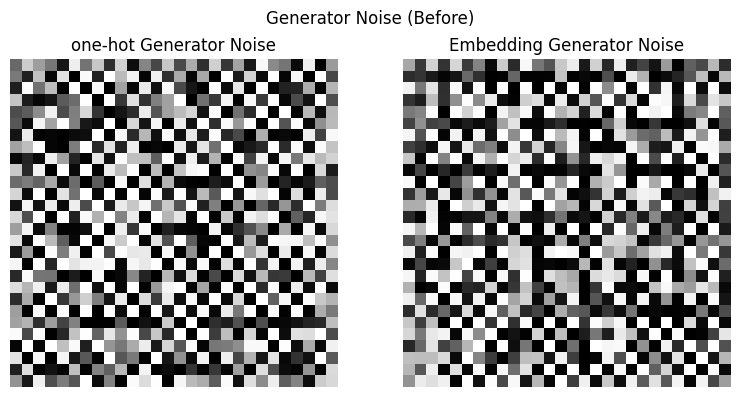

In [14]:
# 초기 노이즈시각화
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(fake_onehot.squeeze().detach().numpy(), cmap='gray')
axes[0].set_title('one-hot Generator Noise')
axes[0].axis('off')

axes[1].imshow(fake_embed.squeeze().detach().numpy(), cmap='gray')
axes[1].set_title('Embedding Generator Noise')
axes[1].axis('off')

plt.suptitle('Generator Noise (Before)')
plt.tight_layout()
plt.show()

shape와 초기 노이즈를 확인했을 때, 올바르게 설계된 것을 확인할 수 있었다.

### 3-2. Discriminator 생성

In [15]:
#One-hot 버전 판별자
class Discriminator_OneHot(nn.Module):
  def __init__(self, num_classes = 10) :
    super(Discriminator_OneHot, self).__init__()
    self.downsample = nn.Sequential(

        # (batch, 11, 28, 28) → (batch, 64, 14, 14)
        nn.Conv2d(1 + num_classes, 64, 4, 2, 1, bias = False),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace = True),

        # (batch, 64, 14, 14) → (batch, 128, 7, 7)
        nn.Conv2d(64, 128, 4, 2, 1, bias = False),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace = True),

         # (batch, 128, 7, 7) → (batch, 1, 1, 1)
        nn.Conv2d(128, 1, 7, 1, 0, bias = False)
    )
    self.sigmoid = nn.Sigmoid()

  def forward(self, image, label) :
    # label → one-hot → 이미지 크기로 펼치기
      label_onehot = F.one_hot(label, num_classes=10)              # (batch, 10)
      label_onehot = label_onehot.view(-1, 10, 1, 1).float()      # (batch, 10, 1, 1)
      label_onehot = label_onehot.expand(-1, 10, 28, 28)          # (batch, 10, 28, 28)

      x = torch.cat([image, label_onehot], dim=1)                 # (batch, 11, 28, 28)
      x = self.downsample(x)                                       # (batch, 1, 1, 1)
      x = self.sigmoid(x)
      return x.view(-1, 1)                                         # (batch, 1)

In [16]:
#Embedding 버전 판별
class Discriminator_Embedding(nn.Module):
  def __init__(self, num_classes = 10) :
    super(Discriminator_Embedding, self).__init__()
    self.embedding = nn.Embedding(num_classes, num_classes)
    self.downsample = nn.Sequential(

        # (batch, 11, 28, 28) → (batch, 64, 14, 14)
        nn.Conv2d(1 + num_classes, 64, 4, 2, 1, bias = False),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace = True),

        # (batch, 64, 14, 14) → (batch, 128, 7, 7)
        nn.Conv2d(64, 128, 4, 2, 1, bias = False),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace = True),

         # (batch, 128, 7, 7) → (batch, 1, 1, 1)
        nn.Conv2d(128, 1, 7, 1, 0, bias = False)
    )
    self.sigmoid = nn.Sigmoid()

  def forward(self, image, label) :
    # label → one-hot → 이미지 크기로 펼치기
      # Embedding 방식
      emb = self.embedding(label)                        # (batch, 10)
      emb = emb.view(-1, 10, 1, 1).float()            # (batch, 10, 1, 1)
      emb = emb.expand(-1, 10, 28, 28)                # (batch, 10, 28, 28)

      x = torch.cat([image, emb], dim=1)                 # (batch, 11, 28, 28)
      x = self.downsample(x)                             # (batch, 1, 1, 1)
      x = self.sigmoid(x)
      return x.view(-1, 1)                               # (batch, 1)

## 4\. 학습/평가, 시각화

In [17]:
# -1~1사이 값을 0~255로 스케일 : fid 계산 위해서
def denorm(x):
    x = (x + 1) / 2                # -1~1 → 0~1
    x = x.repeat(1, 3, 1, 1)      # 1채널 → 3채널
    x = (x * 255).byte()           # 0~1 → 0~255
    return x

In [18]:
#device 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# 카테고리별 고정 noise (매번 같은 noise로 생성해서 비교)
fixed_noise = torch.randn(10, 100, 1, 1).to(device)
fixed_labels = torch.arange(0, 10).to(device)  # 0~9 클래스 하나씩

#평가 지표 설정
psnr= PeakSignalNoiseRatio(data_range = 1.0).to(device)
fid = FrechetInceptionDistance().to(device)

cuda


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 98.0MB/s]


### 4-1. One-Hot 버전 학습

손실함수로는, BCELOSS대신 보다 안정적인 LSGANLoss(MSELoss)를 사용했다.

In [19]:
#One-Hot 버전 학습/평가
epochs = 30

#One-Hot모델 초기화
netG_OneHot = Generator_OneHot(noise_dim=100).to(device)
netD_OneHot = Discriminator_OneHot().to(device)

#손실함수 설정
criterion = nn.MSELoss()

#옵티마이저 설정
G_OneHot_optimizer = optim.Adam(netG_OneHot.parameters(), lr=0.0002)
D_OneHot_optimizer = optim.Adam(netD_OneHot.parameters(), lr=0.0001)


OneHot_history = {
    'G_loss': [],
    'D_loss': [],
    'psnr' : [],
    'fid' : [],
    'time' : 0.0
}

best_fid = float('inf')
os.makedirs('results/OneHot', exist_ok=True)
os.makedirs('checkpoints', exist_ok = True)
print('학습 시작')
start_time = time.time()
for epoch in range(epochs):
    G_loss_sum = 0
    D_loss_sum = 0
    psnr.reset()
    fid.reset()
    for step, (image, label) in enumerate(loader) :
      image = image.to(device)
      label = label.to(device)
      #첫번째 이미지의 크기
      batch_size = image.size(0)

      # 진짜/가짜 라벨
      real = torch.ones(batch_size, 1).to(device)   # 1
      fake = torch.zeros(batch_size, 1).to(device)  # 0

      #학습마다 랜덤 노이즈 생성
      noise = torch.randn(batch_size, 100, 1, 1).to(device)

      #판별자 학습
      netD_OneHot.zero_grad()
      #실제 이미지
      real_image = netD_OneHot(image, label)
      D_real_loss = criterion(real_image, real)

      #가짜 이미지
      fake_image = netG_OneHot(noise, label)
      d_fake = netD_OneHot(fake_image.detach(), label)
      D_fake_loss = criterion(d_fake, fake)

      #판별자 손실 계산
      D_onehot_loss = D_real_loss + D_fake_loss

      #판별자 가중치 업데이트
      D_onehot_loss.backward()
      D_OneHot_optimizer.step()

      #생성자 학습
      netG_OneHot.zero_grad()
      #가짜 이미지
      d_fake = netD_OneHot(fake_image, label)
      G_onehot_loss = criterion(d_fake, real)  # 가짜를 진짜로 속이기
      G_onehot_loss.backward()
      G_OneHot_optimizer.step()

      G_loss_sum += G_onehot_loss.item()
      D_loss_sum += D_onehot_loss.item()

      psnr.update((fake_image.detach() + 1) / 2, (image + 1) / 2)
      #fid는 10 step마다 계산(효율성 때)
      if (step+1) % 10 == 0 :
        fid.update(denorm(image.detach()), real = True)
        fid.update(denorm(fake_image.detach()), real=False)
        print('.', end='', flush=True)

    #history 저장 / epoch마다 출력
    avg_G_loss = G_loss_sum / len(loader)
    avg_D_loss = D_loss_sum / len(loader)
    psnr_avg = psnr.compute().item()
    fid_avg = fid.compute().item()

    OneHot_history['G_loss'].append(avg_G_loss)
    OneHot_history['D_loss'].append(avg_D_loss)
    OneHot_history['psnr'].append(psnr_avg)
    OneHot_history['fid'].append(fid_avg)

    print(f'\nEpoch [{epoch+1}/{epochs}] ')
    print(f'D_loss: {avg_D_loss:.4f}, G_loss: {avg_G_loss:.4f}')
    print(f'PSNR : {psnr_avg}, Fid : {fid_avg}')

    #10 epoch마다 카테고리별 생성된 이미지 출력
    if (epoch + 1) % 10 == 0 :
      netG_OneHot.eval()
      with torch.no_grad():
          fake_images = netG_OneHot(fixed_noise, fixed_labels)  # (10, 1, 28, 28)

      fig, axes = plt.subplots(1, 10, figsize=(20, 2))
      for i, ax in enumerate(axes):
          ax.imshow(fake_images[i].squeeze().cpu().numpy(), cmap='gray')
          ax.set_title(class_names[i], fontsize=7)
          ax.axis('off')
      plt.suptitle(f'Epoch {epoch+1}')
      plt.tight_layout()
      plt.savefig(f'results/OneHot/epoch_{epoch+1}.png')
      plt.close()
      netG_OneHot.train()

    if fid_avg < best_fid:
        best_fid = fid_avg
        torch.save(netG_OneHot.state_dict(), './checkpoints/best_netG_OneHot.pt')
        torch.save(netD_OneHot.state_dict(), './checkpoints/best_netD_OneHot.pt')
        print(f'best model saved! : Best Epoch : {epoch + 1}, Fid : {best_fid}')

end_time = time.time()
OneHot_history['time'] = end_time - start_time
print(f'학습 종료, 걸린 시간 : {OneHot_history["time"]:.2f}')

학습 시작
..............................................
Epoch [1/30] 
D_loss: 0.0567, G_loss: 0.8423
PSNR : 6.13661527633667, Fid : 340.2297668457031
best model saved! : Best Epoch : 1, Fid : 340.2297668457031
..............................................
Epoch [2/30] 
D_loss: 0.1454, G_loss: 0.7272
PSNR : 8.033432006835938, Fid : 216.1239013671875
best model saved! : Best Epoch : 2, Fid : 216.1239013671875
..............................................
Epoch [3/30] 
D_loss: 0.3107, G_loss: 0.5139
PSNR : 9.002924919128418, Fid : 187.2916717529297
best model saved! : Best Epoch : 3, Fid : 187.2916717529297
..............................................
Epoch [4/30] 
D_loss: 0.2993, G_loss: 0.5263
PSNR : 9.078681945800781, Fid : 167.75823974609375
best model saved! : Best Epoch : 4, Fid : 167.75823974609375
..............................................
Epoch [5/30] 
D_loss: 0.3072, G_loss: 0.4962
PSNR : 9.098949432373047, Fid : 147.2487335205078
best model saved! : Best Epoch : 5, Fid : 1

10 epoch마다 각 카테고리별 출력이미지를 저장해서, 학습 후 한번에 관찰하여 학습 현황을 관찰했다.

### 4-2. Embedding 버전 학습

In [20]:
# Embedding 버전 학습/평가
epochs = 30

# Embedding 모델 초기화
netG_Embed = Generator_Embedding(noise_dim=100).to(device)
netD_Embed = Discriminator_Embedding().to(device)

# 손실함수 설정
criterion = nn.MSELoss()

# 옵티마이저 설정
G_Embed_optimizer = optim.Adam(netG_Embed.parameters(), lr=0.0002)
D_Embed_optimizer = optim.Adam(netD_Embed.parameters(), lr=0.0001)

Embed_history = {
    'G_loss': [],
    'D_loss': [],
    'psnr' : [],
    'fid' : [],
    'time' : 0.0
}

best_fid = float('inf')
os.makedirs('results/Embed', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
print('학습 시작')
start_time = time.time()
for epoch in range(epochs):
    G_loss_sum = 0
    D_loss_sum = 0
    psnr.reset()
    fid.reset()
    for step, (image, label) in enumerate(loader):
        image = image.to(device)
        label = label.to(device)
        batch_size = image.size(0)

        real = torch.ones(batch_size, 1).to(device)
        fake = torch.zeros(batch_size, 1).to(device)
        noise = torch.randn(batch_size, 100, 1, 1).to(device)

        # 판별자 학습
        netD_Embed.zero_grad()
        real_image = netD_Embed(image, label)
        D_real_loss = criterion(real_image, real)

        fake_image = netG_Embed(noise, label)
        d_fake = netD_Embed(fake_image.detach(), label)
        D_fake_loss = criterion(d_fake, fake)

        D_embed_loss = D_real_loss + D_fake_loss
        D_embed_loss.backward()
        D_Embed_optimizer.step()

        # 생성자 학습
        netG_Embed.zero_grad()
        d_fake = netD_Embed(fake_image, label)
        G_embed_loss = criterion(d_fake, real)
        G_embed_loss.backward()
        G_Embed_optimizer.step()

        G_loss_sum += G_embed_loss.item()
        D_loss_sum += D_embed_loss.item()

        psnr.update((fake_image.detach() + 1) / 2, (image + 1) / 2)
        if (step+1) % 10 == 0:
            fid.update(denorm(image.detach()), real=True)
            fid.update(denorm(fake_image.detach()), real=False)
            print('.', end='', flush=True)

    avg_G_loss = G_loss_sum / len(loader)
    avg_D_loss = D_loss_sum / len(loader)
    psnr_avg = psnr.compute().item()
    fid_avg = fid.compute().item()

    Embed_history['G_loss'].append(avg_G_loss)
    Embed_history['D_loss'].append(avg_D_loss)
    Embed_history['psnr'].append(psnr_avg)
    Embed_history['fid'].append(fid_avg)

    print(f'\nEpoch [{epoch+1}/{epochs}] ')
    print(f'D_loss: {avg_D_loss:.4f}, G_loss: {avg_G_loss:.4f}')
    print(f'PSNR : {psnr_avg}, Fid : {fid_avg}')

    if (epoch + 1) % 10 == 0:
        netG_Embed.eval()
        with torch.no_grad():
            fake_images = netG_Embed(fixed_noise, fixed_labels)

        fig, axes = plt.subplots(1, 10, figsize=(20, 2))
        for i, ax in enumerate(axes):
            ax.imshow(fake_images[i].squeeze().cpu().numpy(), cmap='gray')
            ax.set_title(class_names[i], fontsize=7)
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(f'results/Embed/epoch_{epoch+1}.png')
        plt.close()
        netG_Embed.train()

    if fid_avg < best_fid:
        best_fid = fid_avg
        torch.save(netG_Embed.state_dict(), './checkpoints/best_netG_Embed.pt')
        torch.save(netD_Embed.state_dict(), './checkpoints/best_netD_Embed.pt')
        print(f'best model saved! : Best Epoch : {epoch}, Fid : {best_fid}')

end_time = time.time()
Embed_history['time'] = end_time - start_time
print(f'학습 종료, 걸린 시간 : {Embed_history["time"]:.2f}초')

학습 시작
..............................................
Epoch [1/30] 
D_loss: 0.2593, G_loss: 0.5557
PSNR : 6.868212699890137, Fid : 287.31195068359375
best model saved! : Best Epoch : 0, Fid : 287.31195068359375
..............................................
Epoch [2/30] 
D_loss: 0.1603, G_loss: 0.6438
PSNR : 7.911742687225342, Fid : 225.59573364257812
best model saved! : Best Epoch : 1, Fid : 225.59573364257812
..............................................
Epoch [3/30] 
D_loss: 0.3406, G_loss: 0.4337
PSNR : 8.702274322509766, Fid : 173.77615356445312
best model saved! : Best Epoch : 2, Fid : 173.77615356445312
..............................................
Epoch [4/30] 
D_loss: 0.3490, G_loss: 0.4181
PSNR : 9.081093788146973, Fid : 153.79443359375
best model saved! : Best Epoch : 3, Fid : 153.79443359375
..............................................
Epoch [5/30] 
D_loss: 0.3712, G_loss: 0.3942
PSNR : 9.227487564086914, Fid : 149.89242553710938
best model saved! : Best Epoch : 4, Fid :

### 4-3. One-Hot, Embedding 비교분석

#### a) Loss 비교

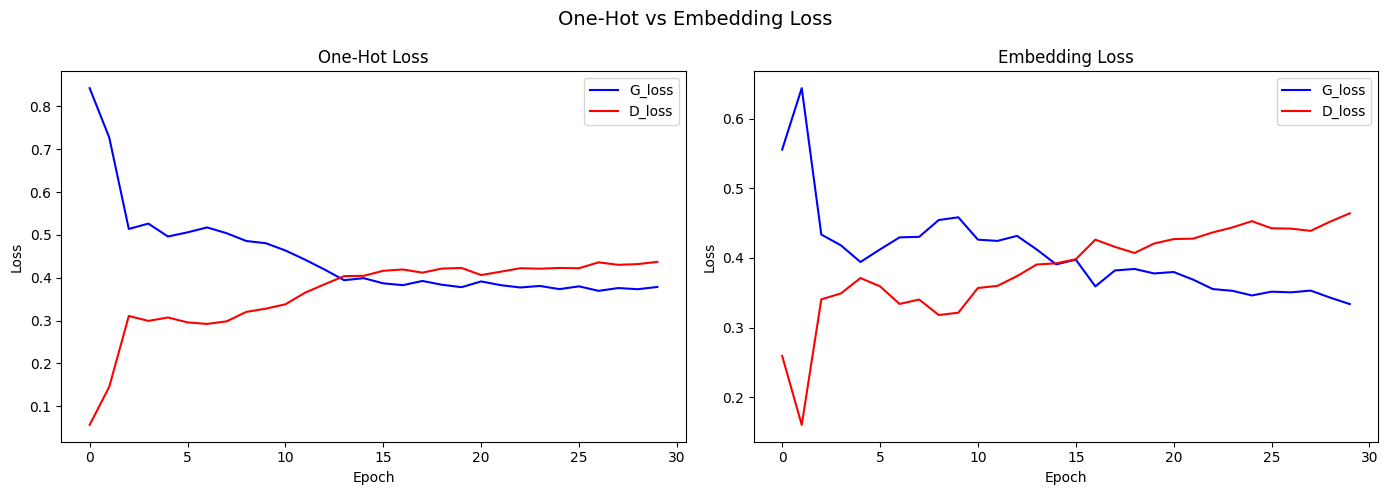

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# One-Hot G_loss, D_loss
axes[0].plot(OneHot_history['G_loss'], label='G_loss', color='blue')
axes[0].plot(OneHot_history['D_loss'], label='D_loss', color='red')
axes[0].set_title('One-Hot Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Embedding G_loss, D_loss
axes[1].plot(Embed_history['G_loss'], label='G_loss', color='blue')
axes[1].plot(Embed_history['D_loss'], label='D_loss', color='red')
axes[1].set_title('Embedding Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('One-Hot vs Embedding Loss', fontsize=14)
plt.tight_layout()
plt.show()

One-Hot Encoding으로 라벨을 추가한 경우에는 ,G_Loss과 D_loss의 합이 작아지면서 수렴하는 그래프의 형태가 보였는데, Embedding으로 라벨링을 진행했을 때에는 오른쪽으로 갈수록 다시 발산하는 파형을 보여, 학습이 잘 되지 않음을 관찰할 수 있었다.

#### b) PSNR 비교

PSNR : 원본과 복원 이미지 간의 평균제곱오차(MSE)에 기반해 신호 대 잡음 비율을 데시벨 단위로 나타낸 품질 지표

-> 값이 클수록 품질이 복원 품질이 좋음, **But GAN에서 크게 의미있지는 않아 참고용**

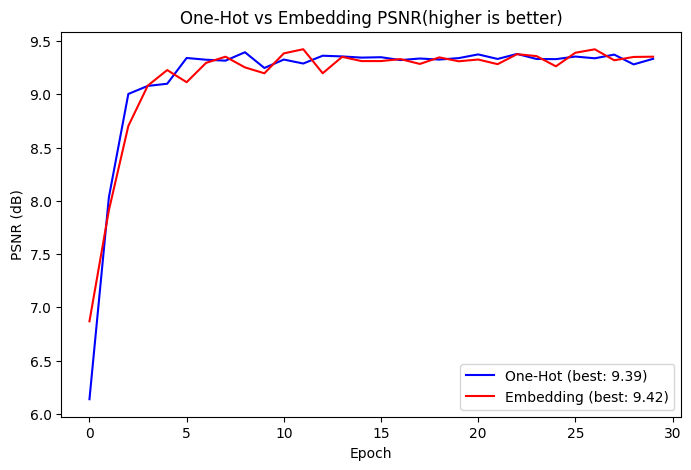

In [22]:
#PSNR 비교
# best PSNR 값 찾기
best_onehot_psnr = max(OneHot_history['psnr'])  # 높을수록 좋음
best_embed_psnr = max(Embed_history['psnr'])

plt.figure(figsize=(8, 5))
plt.plot(OneHot_history['psnr'], label=f'One-Hot (best: {best_onehot_psnr:.2f})', color='blue')
plt.plot(Embed_history['psnr'], label=f'Embedding (best: {best_embed_psnr:.2f})', color='red')
plt.title('One-Hot vs Embedding PSNR(higher is better)')
plt.xlabel('Epoch')
plt.ylabel('PSNR (dB)')
plt.legend()
plt.show()

PSNR의 경우, One-Hot방식과 Embdedding 방식의 지표가 비슷하게 나왔다.

#### c) Fid 비교

Fid : 실제 이미지 분포 vs 생성 이미지 분포의 거리
-> 거리가 가까울수록 = 생성 이미지가 실제와 비슷 : **낮을수록 좋음**

- FID = 0      → 완벽하게 같은 분포 (현실적으로 불가능)

- FID < 50     → 꽤 좋은 편

- FID < 20     → 매우 좋은 편

- FID > 100    → 학습이 잘 안된 것

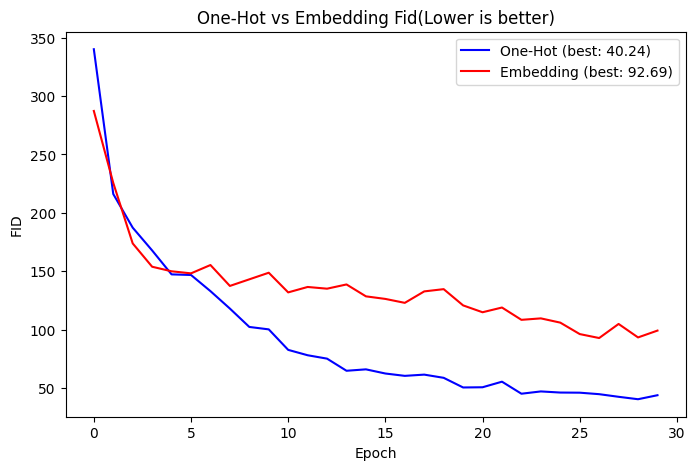

In [23]:
#Fid 비교
#best Fid값 찾기
best_onehot_fid = min(OneHot_history['fid']) #낮을수록 좋음
best_embed_fid = min(Embed_history['fid'])

plt.figure(figsize=(8, 5))
plt.plot(OneHot_history['fid'], label=f'One-Hot (best: {best_onehot_fid:.2f})', color='blue')
plt.plot(Embed_history['fid'], label=f'Embedding (best: {best_embed_fid:.2f})', color='red')
plt.title('One-Hot vs Embedding Fid(Lower is better)')
plt.xlabel('Epoch')
plt.ylabel('FID')
plt.legend()
plt.show()

Embedding 방식의 경우, Fid값이 100 가까이 나온것으로 보아 학습이 잘 되지 않은것으로 보인다.

#### d) 생성 이미지 비교

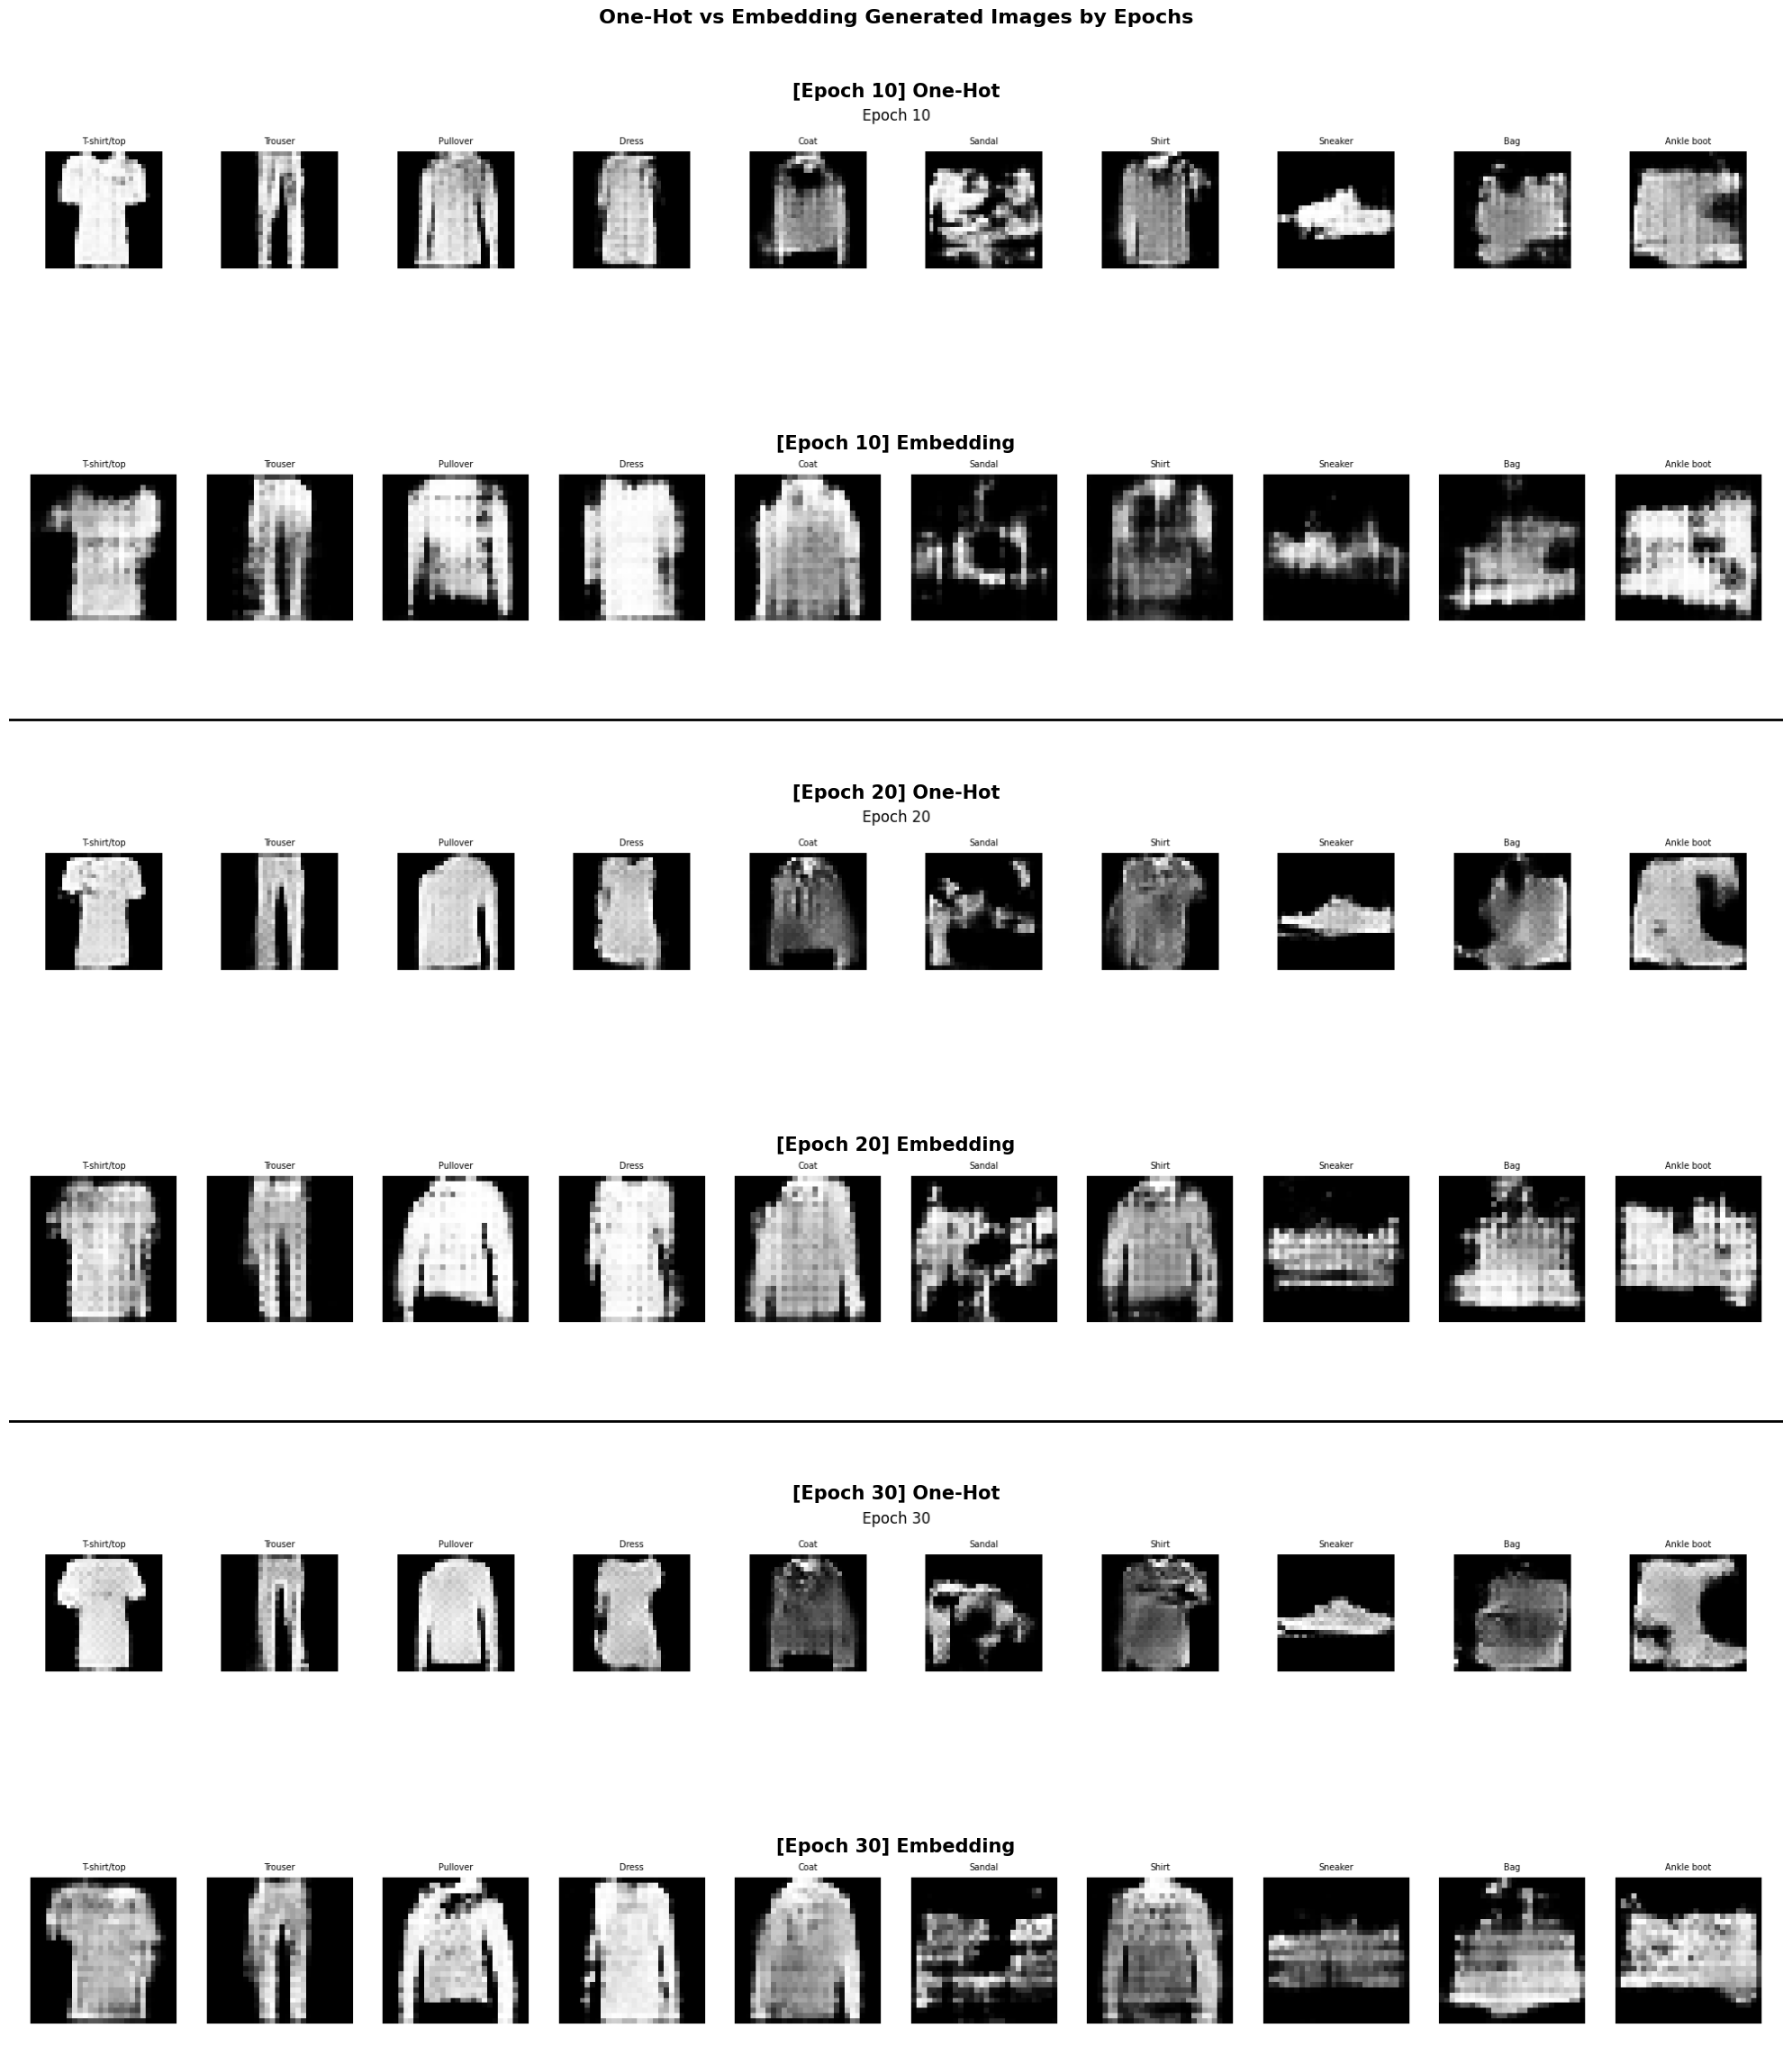

In [25]:
# 에폭당 2개 이미지 + 1개 구분선 (마지막 제외)
saved_epochs = range(10, 31, 10)
total_rows = len(saved_epochs) * 2 + (len(saved_epochs) - 1)
height_ratios = []
for i in range(len(saved_epochs)):
    height_ratios.extend([4, 4])  # 이미지 2개
    if i < len(saved_epochs) - 1:
        height_ratios.append(0.1)  # 구분선

fig, axes = plt.subplots(total_rows, 1, figsize=(20, sum(height_ratios)),
                          gridspec_kw={'height_ratios': height_ratios})

row = 0
for i, epoch in enumerate(saved_epochs):
    img_onehot = mpimg.imread(f'results/OneHot/epoch_{epoch}.png')
    axes[row].imshow(img_onehot)
    axes[row].set_title(f'[Epoch {epoch}] One-Hot', fontsize=15, fontweight='bold')
    axes[row].axis('off')
    row += 1

    img_embed = mpimg.imread(f'results/Embed/epoch_{epoch}.png')
    axes[row].imshow(img_embed)
    axes[row].set_title(f'[Epoch {epoch}] Embedding', fontsize=15, fontweight='bold')
    axes[row].axis('off')
    row += 1

    # 구분선 axes
    if i < len(saved_epochs) - 1:
        axes[row].axhline(y=0.5, color='black', linewidth=2)
        axes[row].axis('off')
        row += 1

plt.suptitle('One-Hot vs Embedding Generated Images by Epochs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

One-Hot encoding의 경우가 더 선명한 사진이 나오는 것을 확인할 수있다.

#### e) 학습 시간 비교

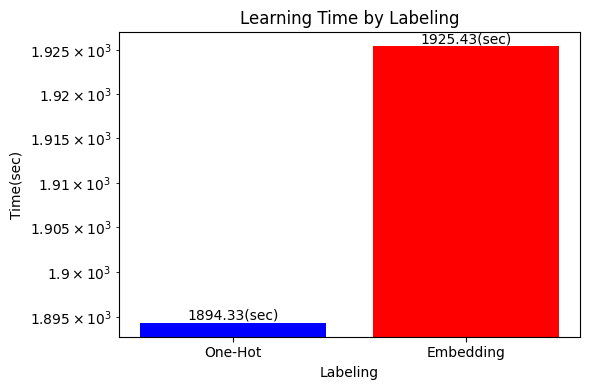

In [26]:
#학습시간 비교
plt.figure(figsize=(6, 4))

models = ['One-Hot', 'Embedding']
times = [OneHot_history['time'], Embed_history['time']]

plt.bar(models, times, color=['blue', 'red'])
plt.title('Learning Time by Labeling')
plt.xlabel('Labeling')
plt.ylabel('Time(sec)')
plt.yscale('log')

# 막대 위에 값 표시
for i, t in enumerate(times): # 'time' 변수 이름을 't_val'로 변경
    plt.text(i, t, f'{t:.2f}(sec)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

결론 : Embedding의 경우에는 One-hot Encoding보다 시간도 오래걸렸고, 학습도 제대로 되지 않았다. 차원의 개수의 문제일 수 있지만, 공정하게 10차원으로 라벨링을 진행했기 때문에, **MNIST데이터셋에서 Embedding 보다 One-Hot으로 라벨링을 진행하는 것이 효과적**이라고 결론이 나왔다

one-hot  → 클래스 구분이 명확 (0 아니면 1) :단순한 데이터에 더 적합

Embedding → 클래스간 관계를 학습, 복잡한 데이터일수록 강점이 드러남

요약 : **FashionMNIST처럼 단순한 데이터셋에서는 one-hot이 Embedding보다 효과적이다 !**

## 5\. 추가 : Diffusion(LDM) 모델

### 5-1. VAE

LDM 모델을 생성하기 위해, 사전학습된 VAE 모델을 가져오려 했지만, 28 x 28사이즈에 맞는 사전학습된 VAE가 없어 직접 구현하였다.

VAE에 사용할 Loss : Reconstruction Loss + KL Divergence

- Reconstruction Loss : 복원 품질

- KL Divergence : 잠재 공간 정규화

In [43]:
class VAE(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),   # (1, 28, 28) → (32, 28, 28)
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # (32, 28, 28) → (64, 14, 14)
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1), # (64, 14, 14) → (128, 7, 7)
            nn.ReLU(),
        )

        # mu, log_var (채널 방향으로 출력)
        self.fc_mu  = nn.Conv2d(128, latent_channels, 1)  # (128, 7, 7) → (4, 7, 7)
        self.fc_var = nn.Conv2d(128, latent_channels, 1)  # (128, 7, 7) → (4, 7, 7)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 128, 1),  # (4, 7, 7) → (128, 7, 7)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),         # (128, 7, 7) → (64, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),          # (64, 14, 14) → (32, 28, 28)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, 1, 1),           # (32, 28, 28) → (1, 28, 28)
            nn.Sigmoid()
        )
    #이미지 -> 잠재 공간의 분포(평균, 분산)으로 변환
    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        return mu, log_var
    #그냥 샘플링을 진행하면 역전파가 불가능, eps를 따로 샘플링하여 곱해서 역전파 가능하도록 함수 생성
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    #이미지 복원
    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)          #인코딩
        z = self.reparameterize(mu, log_var)  #샘플링
        recon = self.decode(z)                #디코딩
        #recon : 복원된 이미지, mu : 평균, log_var : 분
        return recon, mu, log_var

#VAE에 사용할 Loss 정의(복원 품질 + kl_Loss)
def vae_loss(recon, x, mu, log_var, kl_weight = 0.01):
    # 1. Reconstruction Loss (복원 품질)
    recon_loss = F.mse_loss(recon, x, reduction='sum')

    # 2. KL Divergence (잠재 공간 정규화)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return recon_loss + kl_loss * kl_weight

### 5-2. Time-Embedding(시간 임베딩 클래스)

In [28]:
# 타임 임베딩 (U-Net이 현재 '단계'를 알게 해줌)
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Linear(dim, dim)

    def forward(self, t):
        # 트랜스 포머 구조에서 사용하는 포지셔널 인코딩 (트랜스포머 참고)
        inv_freq = 1.0 / (10000 ** (torch.arange(0, self.dim, 2).float() / self.dim)).to(t.device)
        pos_enc_a = torch.sin(t.repeat(1, self.dim // 2) * inv_freq)
        pos_enc_b = torch.cos(t.repeat(1, self.dim // 2) * inv_freq)
        pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=-1)
        return self.proj(pos_enc)

### 5-3. Latent U-Net

In [29]:
class LatentUNet(nn.Module):
    def __init__(self, latent_channels=4, time_dim=64, num_classes=10):
        super().__init__()

        # Time Embedding
        self.time_mlp = TimeEmbedding(time_dim)

        # 클래스 조건 (one-hot 10차원 → time_dim으로 변환)
        self.class_emb = nn.Linear(num_classes, time_dim)

        # time + class 조건을 채널에 더해주기 위한 projection
        self.time_proj = nn.Linear(time_dim, 64)

        # Encoder (Down)
        self.inc   = nn.Conv2d(latent_channels, 64, 3, 1, 1)  # (4, 7, 7) → (64, 7, 7)
        self.down1 = nn.Conv2d(64, 128, 3, 2, 1)              # (64, 7, 7) → (128, 4, 4)
        self.down2 = nn.Conv2d(128, 256, 3, 2, 1)             # (128, 4, 4) → (256, 2, 2)

        # Bottleneck
        self.bot = nn.Conv2d(256, 256, 3, 1, 1)               # (256, 2, 2) → (256, 2, 2)

        # Decoder (Up) + Skip Connection
        self.up1  = nn.ConvTranspose2d(256, 128, 4, 2, 1)               # (256, 2, 2) → (128, 4, 4)
        self.up2  = nn.ConvTranspose2d(256, 64, 3, 2, 1)  # (256, 4, 4) → (64, 7, 7)
        self.outc = nn.Conv2d(128, latent_channels, 3, 1, 1)             # (128, 7, 7) → (4, 7, 7)

    def forward(self, x, t, label):
        # time embedding
        t_emb = self.time_mlp(t.view(-1, 1).float())            # (batch, 64)

        # class embedding (one-hot)
        label_onehot = F.one_hot(label, num_classes=10).float() # (batch, 10)
        c_emb = self.class_emb(label_onehot)                    # (batch, 64)

        # time + class 합치기
        cond = t_emb + c_emb                                    # (batch, 64)
        cond = self.time_proj(cond).view(-1, 64, 1, 1)          # (batch, 64, 1, 1)

        # Encoder
        x1 = F.relu(self.inc(x) + cond)   # (64, 7, 7) skip용
        x2 = F.relu(self.down1(x1))        # (128, 4, 4) skip용
        x3 = F.relu(self.down2(x2))        # (256, 2, 2)

        # Bottleneck
        x3 = F.relu(self.bot(x3))          # (256, 2, 2)

        # Decoder + Skip Connection
        x = self.up1(x3)                        # (256, 2, 2) → (128, 4, 4)
        x = F.relu(torch.cat([x, x2], dim=1))  # (128+128, 4, 4) = (256, 4, 4)

        x = self.up2(x)                         # (256, 4, 4) → (64, 7, 7)
        x = F.relu(torch.cat([x, x1], dim=1))  # (64+64, 7, 7) = (128, 7, 7)

        return self.outc(x)                     # (128, 7, 7) → (4, 7, 7)

### 5-4. DDPM(노이즈 스케줄링)

In [30]:
class DDPM:
    def __init__(self, device, T=1000):
        self.T = T
        self.device = device
        self.beta = torch.linspace(1e-4, 0.02, T).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def add_noise(self, z_0, t):
        # 픽셀 공간 대신 잠재 공간 z에 노이즈 추가
        noise = torch.randn_like(z_0)
        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t]).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar[t]).view(-1, 1, 1, 1)
        return sqrt_alpha_bar * z_0 + sqrt_one_minus_alpha_bar * noise, noise

    @torch.no_grad()
    def sample(self, model, z_shape, label, device):
        # 순수 노이즈에서 시작
        z = torch.randn(z_shape).to(device)

        for t in reversed(range(1, self.T)):
            t_batch = torch.full((z_shape[0],), t, device=device, dtype=torch.long)

            # 노이즈 예측
            predicted_noise = model(z, t_batch, label)

            # 한 스텝 노이즈 제거
            alpha = self.alpha[t]
            alpha_bar = self.alpha_bar[t]
            beta = self.beta[t]

            if t > 1:
                noise = torch.randn_like(z)
            else:
                noise = torch.zeros_like(z)

            z = (1 / torch.sqrt(alpha)) * (z - (1 - alpha) / torch.sqrt(1 - alpha_bar) * predicted_noise) + torch.sqrt(beta) * noise

        return z

### 5-5.학습

In [44]:
# 모델 초기화
vae = VAE(latent_channels=4).to(device)
ldm = LatentUNet(latent_channels=4, time_dim=64, num_classes=10).to(device)
ddpm = DDPM(device=device, T=200)

# VAE, LDM 옵티마이저
vae_optimizer = optim.Adam(vae.parameters(), lr=5e-4)
ldm_optimizer = optim.Adam(ldm.parameters(), lr=5e-5)

# 데이터로더 (0~1 범위!)
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

os.makedirs('results/LDM', exist_ok=True)

psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
#LDM은 FID features 2048로 지
fid = FrechetInceptionDistance(feature=2048).to(device)

ldm_history = {
    'vae_loss': [],
    'ldm_loss': [],
    'psnr' : [],
    'fid' : [],
    'time': 0.0
}

fixed_labels = torch.arange(0, 10).to(device)

epochs = 150
print('LDM 학습 시작')
start_time = time.time()
best_fid = float('inf')

for epoch in range(epochs):
    vae_loss_sum = 0
    ldm_loss_sum = 0
    psnr.reset()

    for step, (image, label) in enumerate(loader):
        image = image.to(device)
        label = label.to(device)

        # VAE 학습
        vae_optimizer.zero_grad()
        recon, mu, log_var = vae(image)
        loss_vae = vae_loss(recon, image, mu, log_var, kl_weight = 0.01)
        loss_vae.backward()
        vae_optimizer.step()
        vae_loss_sum += loss_vae.item()

        # LDM 학습
        ldm_optimizer.zero_grad()
        with torch.no_grad():
            mu, log_var = vae.encode(image)
            z = vae.reparameterize(mu, log_var)

        t = torch.randint(1, ddpm.T, (image.size(0),)).to(device)
        z_t, noise = ddpm.add_noise(z, t)
        predicted_noise = ldm(z_t, t, label)
        loss_ldm = F.mse_loss(predicted_noise, noise)
        loss_ldm.backward()
        ldm_optimizer.step()
        ldm_loss_sum += loss_ldm.item()

        # PSNR (VAE 복원 기준)
        psnr.update(recon.detach(), image)
        if (step+1) % 100 == 0:
          print('.', end='', flush=True)

    avg_vae_loss = vae_loss_sum / len(loader)
    avg_ldm_loss = ldm_loss_sum / len(loader)
    psnr_avg = psnr.compute().item()

    # FID → 생성 이미지 기준으로 계산(5epoch마다)
    fid.reset()
    vae.eval()
    ldm.eval()
    if (epoch + 1) % 5 == 0 :
      with torch.no_grad():
          # 실제 이미지 500장
          count = 0
          for image, _ in loader:
              image = image.to(device)
              real_fid = (image.repeat(1, 3, 1, 1) * 255).byte()
              fid.update(real_fid, real=True)
              count += image.size(0)
              if count >= 500:
                  break

          # 생성 이미지 500장
          for _ in range(500 // 10):
              noise_labels = torch.randint(0, 10, (10,)).to(device)
              z = ddpm.sample(ldm, (10, 4, 7, 7), noise_labels, device)
              fake = vae.decode(z)
              fake_fid = (fake.repeat(1, 3, 1, 1) * 255).byte()
              fid.update(fake_fid, real=False)
      fid_avg = fid.compute().item()
    else :
      fid_avg = float('nan')
    vae.train()
    ldm.train()

    ldm_history['vae_loss'].append(avg_vae_loss)
    ldm_history['ldm_loss'].append(avg_ldm_loss)
    ldm_history['psnr'].append(psnr_avg)
    ldm_history['fid'].append(fid_avg)
    if (epoch+1) % 5 == 0:
      print(f'\nEpoch [{epoch+1}/{epochs}] '
          f'VAE Loss: {avg_vae_loss:.4f} '
          f'LDM Loss: {avg_ldm_loss:.4f} '
          f'PSNR: {psnr_avg:.4f} '
          f'FID: {fid_avg:.4f}')

    if fid_avg < best_fid and epoch > 50:
        best_fid = fid_avg
        torch.save(vae.state_dict(), './checkpoints/best_vae.pt')
        torch.save(ldm.state_dict(), './checkpoints/best_ldm.pt')
        print(f'Best model saved! Epoch: {epoch+1}, FID: {best_fid:.4f}')

    # 50 에폭마다 이미지 생성
    if (epoch+1) % 50 == 0:
        vae.eval()
        ldm.eval()
        with torch.no_grad():
            z_shape = (10, 4, 7, 7)
            z = ddpm.sample(ldm, z_shape, fixed_labels, device)
            fake_images = vae.decode(z)

        fig, axes = plt.subplots(1, 10, figsize=(20, 2))
        for i, ax in enumerate(axes):
            ax.imshow(fake_images[i].squeeze().cpu().numpy(), cmap='gray')
            ax.set_title(class_names[i], fontsize=7)
            ax.axis('off')
        plt.suptitle(f'LDM Epoch {epoch+1}')
        plt.tight_layout()
        plt.savefig(f'results/LDM/epoch_{epoch+1}.png')
        plt.close()
        print(f'Sample saved! LDM/{epoch+1}.png')
        vae.train()
        ldm.train()

torch.save(vae.state_dict(), './checkpoints/vae.pt')
torch.save(ldm.state_dict(), './checkpoints/ldm.pt')

ldm_history['time'] = time.time() - start_time
print('학습 종료, 걸린 시간: {:.2f}초'.format(ldm_history['time']))

LDM 학습 시작
....................
Epoch [5/150] VAE Loss: 739.2228 LDM Loss: 0.5146 PSNR: 23.5810 FID: 174.1031
....................
Epoch [10/150] VAE Loss: 688.2672 LDM Loss: 0.5013 PSNR: 24.0656 FID: 145.9848
....................
Epoch [15/150] VAE Loss: 666.1630 LDM Loss: 0.4970 PSNR: 24.2747 FID: 132.9716
....................
Epoch [20/150] VAE Loss: 653.1180 LDM Loss: 0.4888 PSNR: 24.3996 FID: 124.4907
....................
Epoch [25/150] VAE Loss: 643.9416 LDM Loss: 0.4887 PSNR: 24.4945 FID: 110.3093
....................
Epoch [30/150] VAE Loss: 636.0043 LDM Loss: 0.4894 PSNR: 24.5761 FID: 109.8315
....................
Epoch [35/150] VAE Loss: 630.2604 LDM Loss: 0.4853 PSNR: 24.6364 FID: 110.7890
....................
Epoch [40/150] VAE Loss: 625.5174 LDM Loss: 0.4851 PSNR: 24.6872 FID: 101.9828
....................
Epoch [45/150] VAE Loss: 621.4602 LDM Loss: 0.4859 PSNR: 24.7307 FID: 98.3860
....................
Epoch [50/150] VAE Loss: 618.4578 LDM Loss: 0.4828 PSNR: 24.7622 FID: 9

### 5-6. 프로세스 시각화

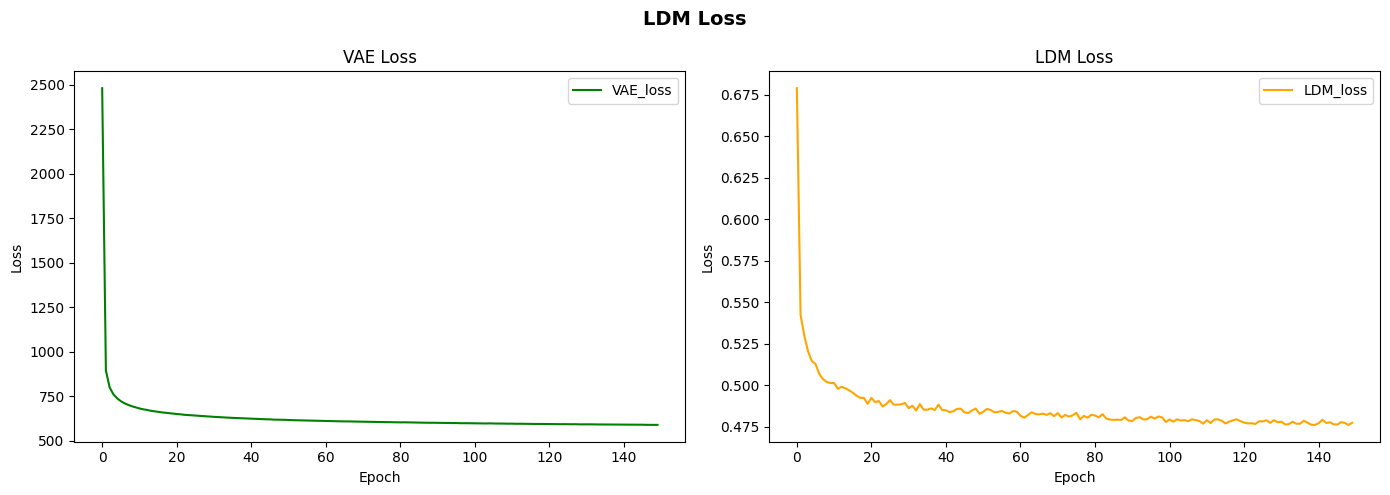

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ldm_history['vae_loss'], label='VAE_loss', color='green')
axes[0].set_title('VAE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ldm_history['ldm_loss'], label='LDM_loss', color='orange')
axes[1].set_title('LDM Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('LDM Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5-7. LDM 성능지표

#### PSNR, FID

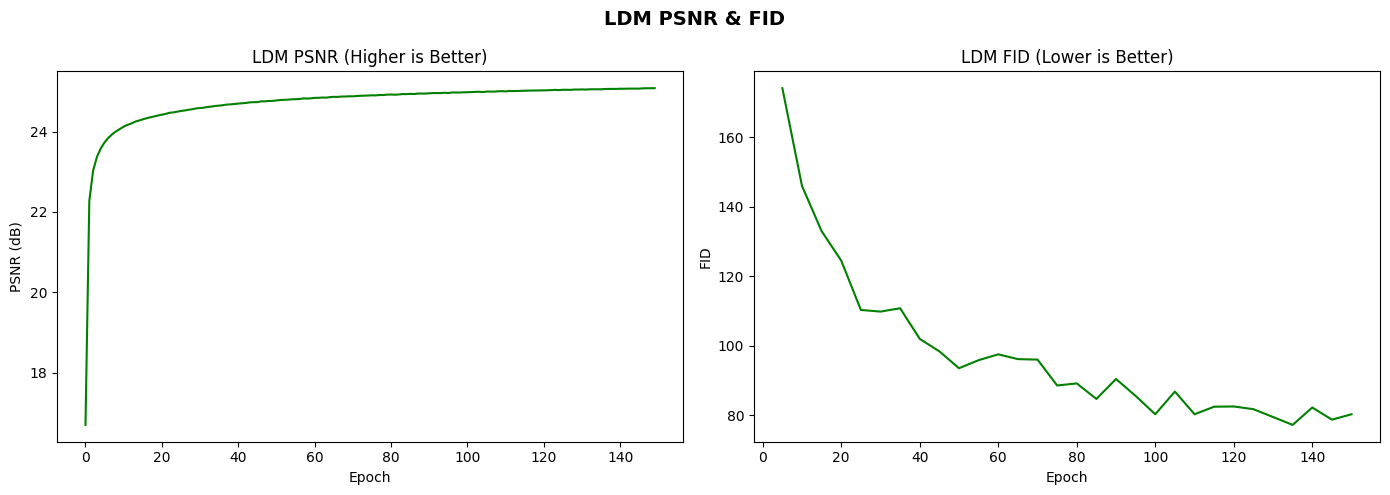

In [47]:
# FID 시각화 위해 nan 제거하고 해당 에폭만 추출
fid_epochs = [i+1 for i, v in enumerate(ldm_history['fid']) if not np.isnan(v)]
fid_values = [v for v in ldm_history['fid'] if not np.isnan(v)]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PSNR
axes[0].plot(ldm_history['psnr'], color='green')
axes[0].set_title('LDM PSNR (Higher is Better)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('PSNR (dB)')

# FID
axes[1].plot(fid_epochs, fid_values, color='green')
axes[1].set_title('LDM FID (Lower is Better)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('FID')

plt.suptitle('LDM PSNR & FID', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 생성 이미지 비교

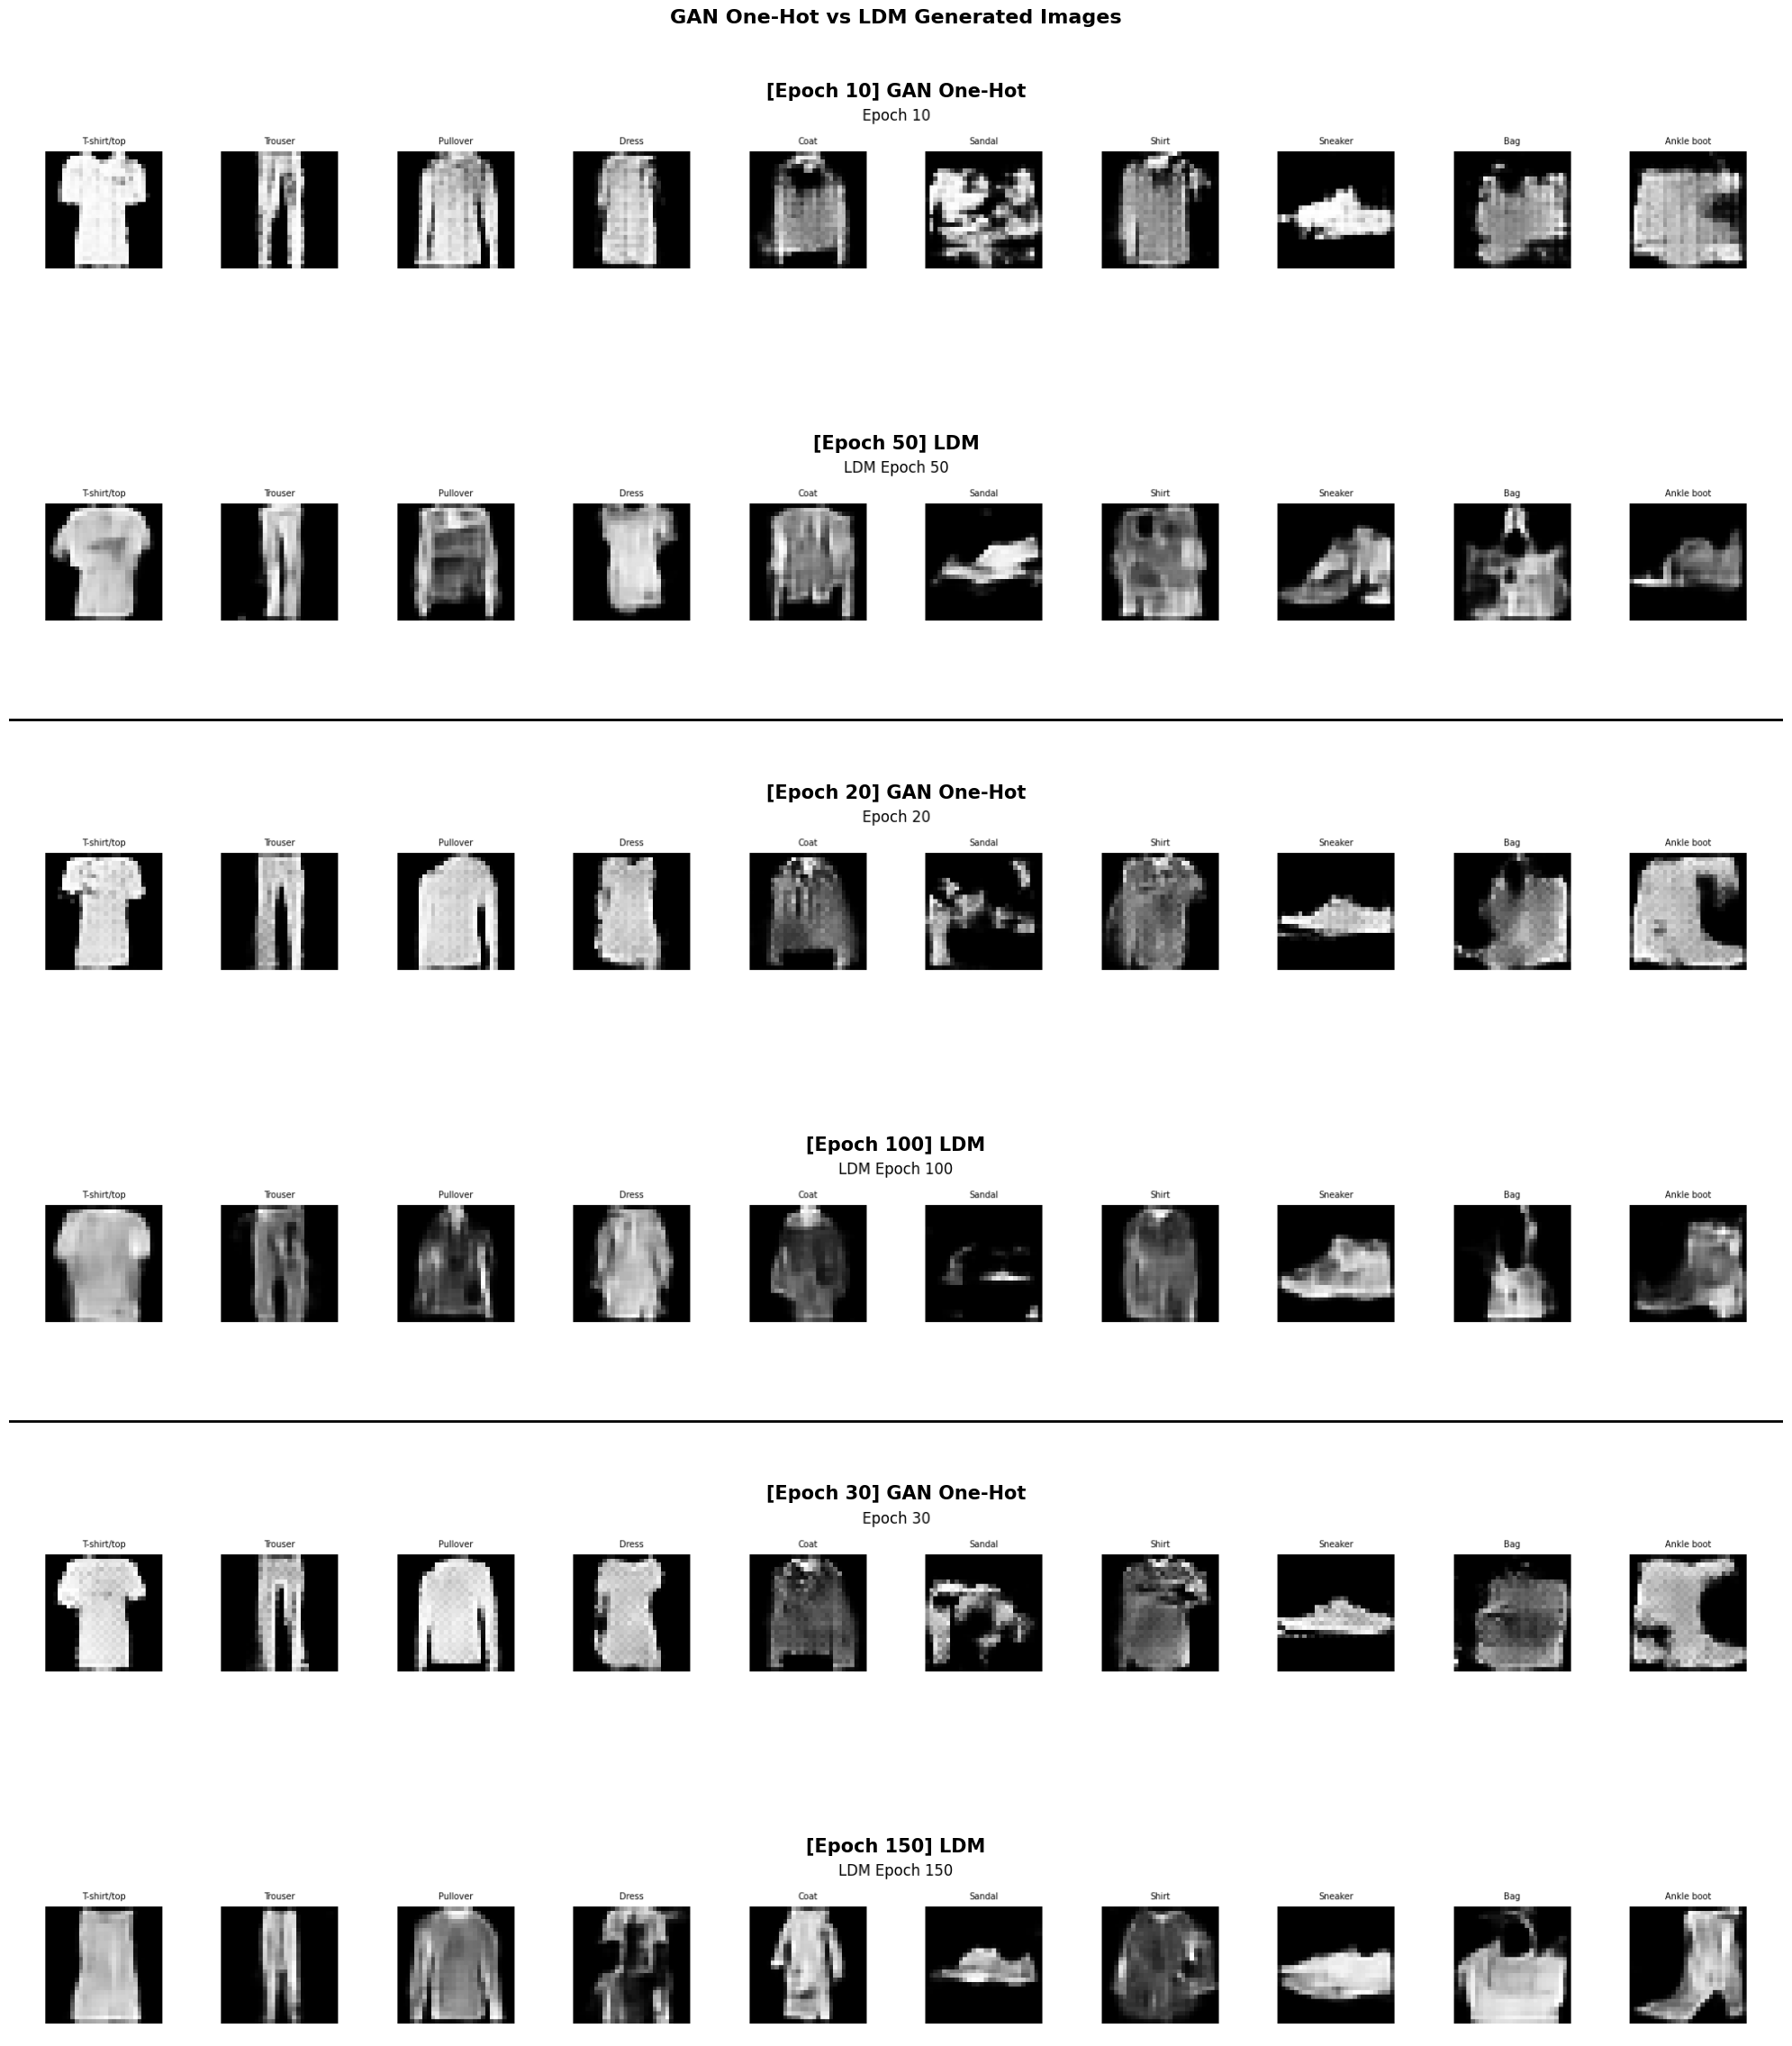

In [49]:
saved_epochs = range(10, 31, 10)
total_rows = len(saved_epochs) * 2 + (len(saved_epochs) - 1)
height_ratios = []
for i in range(len(saved_epochs)):
    height_ratios.extend([4, 4])
    if i < len(saved_epochs) - 1:
        height_ratios.append(0.1)

fig, axes = plt.subplots(total_rows, 1, figsize=(20, sum(height_ratios)),
                          gridspec_kw={'height_ratios': height_ratios})

row = 0
for i, epoch in enumerate(saved_epochs):
    img_onehot = mpimg.imread(f'results/OneHot/epoch_{epoch}.png')
    axes[row].imshow(img_onehot)
    axes[row].set_title(f'[Epoch {epoch}] GAN One-Hot', fontsize=15, fontweight='bold')
    axes[row].axis('off')
    row += 1

    img_ldm = mpimg.imread(f'results/LDM/epoch_{epoch*5}.png')
    axes[row].imshow(img_ldm)
    axes[row].set_title(f'[Epoch {epoch*5}] LDM', fontsize=15, fontweight='bold')
    axes[row].axis('off')
    row += 1

    if i < len(saved_epochs) - 1:
        axes[row].axhline(y=0.5, color='black', linewidth=2)
        axes[row].axis('off')
        row += 1

plt.suptitle('GAN One-Hot vs LDM Generated Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### 학습시간 비교

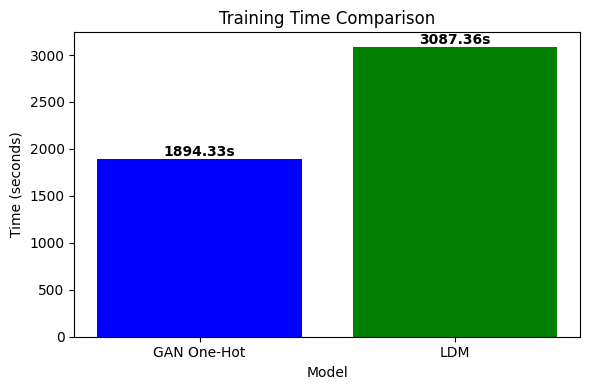

In [50]:
#학습시간 비교
plt.figure(figsize=(6, 4))

models = ['GAN One-Hot', 'LDM']
times = [OneHot_history['time'], ldm_history['time']]

bars = plt.bar(models, times, color=['blue', 'green'])
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Time (seconds)')

# 막대 위에 값 표시
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{t:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6\. 결론

### 1\. One-Hot vs Embedding

One-Hot   -> 단순한 데이터셋에서 더 효과적

Embedding -> 표현력은 풍부하지만
            FashionMNIST처럼 단순한 데이터에서는
            One-Hot보다 학습이 불안정

**-> 데이터셋 복잡도에 따라 조건 주입 방식 선택 필요**

### 2\. GAN vs LDM

GAN -> 학습 빠름, 30에폭으로도 충분,
      모드 붕괴 가능성 있음

LDM -> 학습 오래걸림 (150에폭),
      잠재 공간에서 학습해서 안정적
      FID 78로 알아볼 수 있는 수준